In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

#### Read the dataframe. We use the dataframe created from the previous presentation, titled "Presentation3_df.csv" 

In [2]:
df = pd.read_csv("Presentation3_df.csv")

# run the below line to get a dataframe of the activity names 
    # I created this on my own by identifying the activity names that indicate a successful call outside of the queue hits 
mapped_activity_names = pd.read_excel("activity names.xlsx")
dead_end_activity_names = mapped_activity_names[mapped_activity_names['Success?']==1]['Activity Name'].unique()

In [ ]:
# --------- some  adjustments needed for the columns of the dataframe ------- 
 
# run the below line to get a dataframe of the activity names 

mapped_activity_names = pd.read_excel("activity names.xlsx")

df = df.rename(columns={'call_successful': 'reached_queue'})
df['dead_end_hit'] = df['Activity Name'].isin(dead_end_activity_names)

df['call_successful'] = (
    (df['queue_hit']| df['queue_present'] | df['dead_end_hit'])
      .groupby(df['Contact Session ID'])
      .transform('max')
      .astype(int)
)

def build_node_time_tuples(group):
    pre = group[group["Activity Name"].notna()]

    # now extract clean lists
    nodes = pre["Activity Name"].tolist()
    secs  = pre["seconds_until_next"].astype(float).tolist()
    return list(zip(nodes, secs))

call_level_tuples = df.groupby("Contact Session ID").apply(build_node_time_tuples)
df["node_time_tuples"] = df["Contact Session ID"].map(call_level_tuples)

def extract_pre_queue_path(node_time_list):
    # Keep nodes only up to the first one containing 'Queue' (case-insensitive)
    path = []
    for node, _ in node_time_list:
        if 'queue' in str(node).lower():
            break
        path.append(node)
    return path

def extract_pre_queue_node_times(node_time_list):
    # Keep (node, seconds) tuples only up to the first node containing 'Queue'
    path = []
    for node, sec in node_time_list:
        if 'queue' in str(node).lower():
            break
        path.append((node, sec))
    return path

# Apply per call
df["pre_queue_path_list"] = df["node_time_tuples"].apply(extract_pre_queue_path)
df["pre_queue_node_time_tuples"] = df["node_time_tuples"].apply(extract_pre_queue_node_times)
df["pre_queue_path_str"] = df["pre_queue_path_list"].apply(lambda x: " -> ".join(x))

# Function to sum all seconds in the tuples
def sum_seconds(tuples):
    return sum(seconds for node, seconds in tuples)

df["total_time"] = df["node_time_tuples"].apply(sum_seconds)
df["pre_queue_total_time"] = df["pre_queue_node_time_tuples"].apply(sum_seconds)


In [ ]:
# ------------ create a dataframe at the call level so things don't get too complicated ----------- 
cols_to_keep = [
    "EP Name", "Agent Name", "Termination Reason", 
    "reached_queue",
    "dead_end_hit",
    "call_successful",
    "total_time", 
    "pre_queue_total_time",
    "total_movements",
    "total_unique_nodes",
    "total_repeats_per_call",
    "pre_queue_path_list",
    "full_path_list",
    "node_time_tuples",
    "pre_queue_node_time_tuples"
    # add anything else that is call-level only
]

call_level_df = (df.groupby("Contact Session ID")[cols_to_keep].first().reset_index())
call_level_df.to_csv("call_level_df.csv")

df.to_csv('Presentation4_df.csv')

In [ ]:
# need to convert to actual list. 
import ast 

call_df = pd.read_csv("call_level_df.csv")

cols_to_convert = [
    "pre_queue_path_list",
    "full_path_list",
    "node_time_tuples",
    "pre_queue_node_time_tuples"
]

for col in cols_to_convert:
    call_df[col] = call_df[col].apply(ast.literal_eval)

call_df['final_node'] = call_df['full_path_list'].apply(lambda x: x[-1])
call_df['second_to_last_node'] = call_df['full_path_list'].apply(
    lambda x: x[-2] if len(x) >= 2 else None
)


def second_last_plus_last(path):
    if len(path) == 0:
        return None
    elif len(path) == 1:
        return path[0]  # Only one node
    else:
        return f"{path[-2]} + {path[-1]}"  # Combine second-to-last and last nodes

call_df['second_last_and_last'] = call_df['full_path_list'].apply(second_last_plus_last)


# Get all unique nodes
unique_nodes = sorted({node for path in call_df['full_path_list'] for node in path})

# Convert to DataFrame and export to Excel
unique_nodes_df = pd.DataFrame(unique_nodes, columns=['node_name'])
unique_nodes_df.to_excel('unique_nodes.xlsx', index=False)

second_last_counts = call_df['second_last_and_last'].value_counts().reset_index()
second_last_counts.columns = ['second_last_and_last', 'count']

# Export to Excel
second_last_counts.to_excel('second_last_and_last_counts.xlsx', index=False)


In [ ]:
# get the final queue that a call ends up in 

df= pd.read_csv("Presentation3_df.csv")

unique_queues_per_call = (
    df.groupby("Contact Session ID")["Queue Name"]
    .apply(lambda x: list(pd.unique(x.dropna())))  # keep only unique queue nodes
    .reset_index()
    .rename(columns={"Queue Name": "unique_queues_visited"})
)

# Map back to the main df 
call_df = call_df.merge(unique_queues_per_call, on="Contact Session ID", how="left")


In [ ]:
# export this dataframe as a call level dataframe 
call_df.to_csv("call_level_df_new.csv")

# Analysis

In [ ]:
import ast
call_df = pd.read_csv("call_level_df_new.csv").loc[:, lambda df: ~df.columns.str.contains("Unnamed")]
cols_to_convert = [
    "pre_queue_path_list",
    "full_path_list",
    "node_time_tuples",
    "pre_queue_node_time_tuples", 
    "unique_queues_visited"
]

# need to parse the columns with lists as values to be literal lists instead of strings 
for col in cols_to_convert:
    call_df[col] = call_df[col].apply(ast.literal_eval)

# If unique_queues_visited currently contains a list with one element, extract it
call_df["final_queue"] = call_df["unique_queues_visited"].apply(
    lambda x: x[0] if x else "No_queue_names"
)


## 1. Average Pre Queue Time

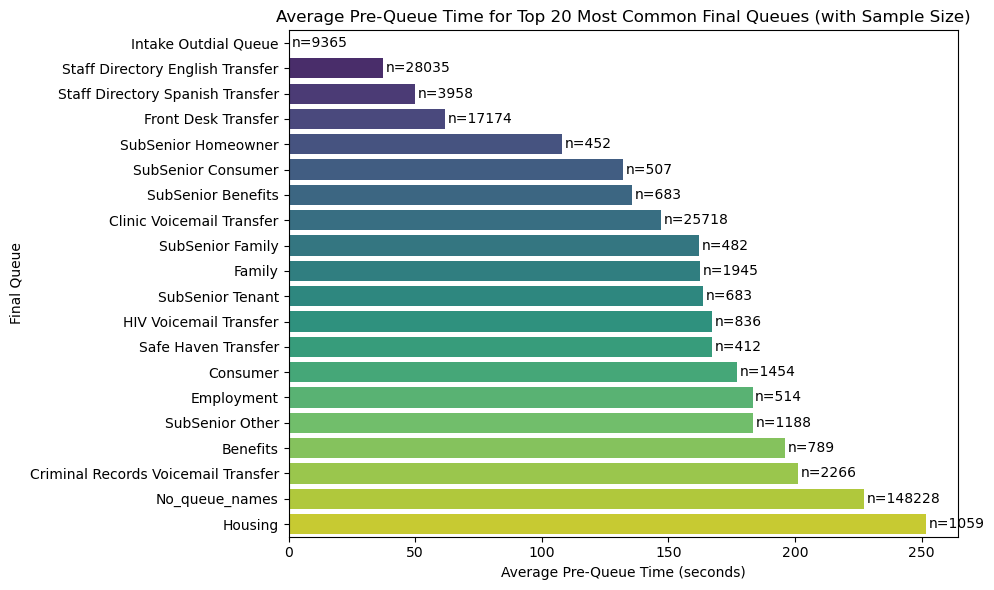

In [ ]:

# Compute avg pre-queue time and sample size per final queue
queue_stats = (
    call_df.groupby("final_queue")
    .agg(
        avg_pre_queue_time_seconds=("pre_queue_total_time", "mean"),
        call_count=("Contact Session ID", "count")
    )
    .reset_index()
)

# Keep only top 20 most common final queues
top_queues = call_df["final_queue"].value_counts().head(20).index
queue_stats_top20 = queue_stats[queue_stats["final_queue"].isin(top_queues)]

# Sort by avg pre-queue time for horizontal bar plot
queue_stats_top20 = queue_stats_top20.sort_values("avg_pre_queue_time_seconds", ascending=True)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=queue_stats_top20,
    y="final_queue",
    x="avg_pre_queue_time_seconds",
    palette="viridis"
)

# Annotate bars with sample size
for i, row in enumerate(queue_stats_top20.itertuples()):
    ax.text(
        row.avg_pre_queue_time_seconds + 1,  # slightly right of bar
        i,  # use the positional index of the bar
        f'n={row.call_count}',
        va='center'
    )

plt.xlabel("Average Pre-Queue Time (seconds)")
plt.ylabel("Final Queue")
plt.title("Average Pre-Queue Time for Top 20 Most Common Final Queues (with Sample Size)")
plt.tight_layout()
plt.show()


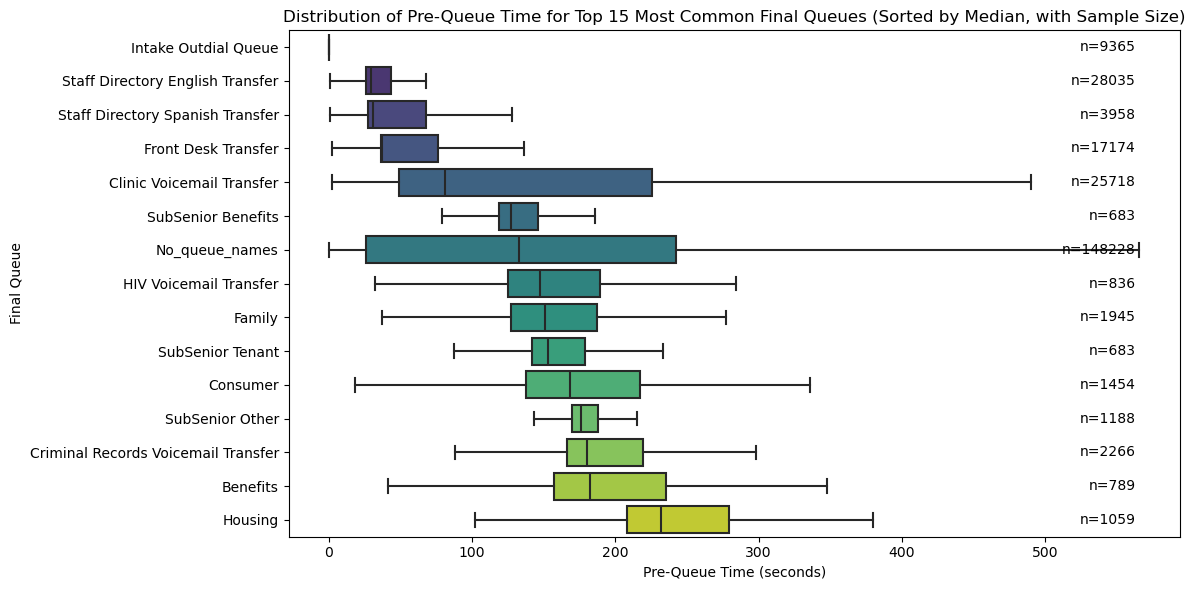

In [11]:
# Top 15 most common final queues
top_queues = call_df["final_queue"].value_counts().head(15).index
df_top15 = call_df[call_df["final_queue"].isin(top_queues)]

# Compute median pre-queue time per queue for sorting
median_times = df_top15.groupby("final_queue")["pre_queue_total_time"].median().sort_values()

# Set the order of queues by median
queue_order = median_times.index.tolist()

# Compute sample sizes
queue_counts = df_top15["final_queue"].value_counts()

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=df_top15,
    y="final_queue",
    x="pre_queue_total_time",
    palette="viridis",
    showfliers=False,
    order=queue_order
)

# Annotate each box with sample size
for i, queue in enumerate(queue_order):
    n = queue_counts.get(queue, 0)
    ax.text(
        0.95,  # relative x-position
        i,     # y-position
        f'n={n}',
        va='center',
        ha='right',
        transform=ax.get_yaxis_transform()
    )

plt.xlabel("Pre-Queue Time (seconds)")
plt.ylabel("Final Queue")
plt.title("Distribution of Pre-Queue Time for Top 15 Most Common Final Queues (Sorted by Median, with Sample Size)")
plt.tight_layout()
plt.show()


## 2. Language Menu Analysis/common paths

In [ ]:
# Count frequency of each full path
path_counts = call_df['full_path_list'].value_counts()

# Top 10 most common paths
top10_paths = path_counts.head(10)

# Total number of calls
total_calls = len(call_df)

# Create summary dataframe
top10_summary = pd.DataFrame({
    'Full Path': [' -> '.join(p[:5]) + ('...' if len(p)>5 else '') if isinstance(p, list) else str(p) 
                  for p in top10_paths.index],
    'Number of Calls': top10_paths.values,
    'Percent of Total Calls': (top10_paths.values / total_calls * 100).round(2)
})

# Add total number of calls as a column (same value for all rows)
top10_summary['Total Calls'] = total_calls

# Display nicely  
    # IMPORTANT: the top 10 most common paths will be displayed as an excel spreadsheet 
top10_summary.to_excel("top10summary.xlsx")


## 3. Other Legal Menu Analysis

In [ ]:
# these nodes correspond to the Other Legal Menu nodes 
problem_nodes = [
    "OtherLegalPersonalInjuryMenu",
    "OtherLegalCriminalCaseMenu",
    "OtherLegalOtherMenu", 
    "OtherLegalMenu"
]

# creating dataframes for each of these submenus that contain only calls that visit these menus. 
node_dfs = {}
for node in problem_nodes:
    subset = call_df[
        call_df['full_path_list'].apply(
            lambda path: isinstance(path, list) and node in path
        )
    ].copy()
    # count appearances of the node 
    subset['num_visits'] = subset['full_path_list'].apply(
        lambda path: path.count(node)
    )

     # --- 3. Time spent on each visit (list) ----------------------------
    # node_times is list of (node_name, seconds)
    subset['time_per_visit'] = subset['node_time_tuples'].apply(
        lambda lst: [t for n, t in lst if n == node]
    )
    
    subset['total_time_on_node'] = subset['time_per_visit'].apply(sum)  
    subset['total_time_first_time'] = subset['time_per_visit'].apply(lambda x: x[0] if len(x) > 0 else None)
    subset['total_time_second_time'] = subset['time_per_visit'].apply(lambda x: x[1] if len(x) > 1 else None)

    # Save DataFrame for this node
    node_dfs[node] = subset


In [ ]:
# getting specific dataframe using what we created above 
otherlegalcriminal = node_dfs['OtherLegalCriminalCaseMenu']
otherlegal = node_dfs['OtherLegalMenu']
otherlegalpersonalinjury = node_dfs['OtherLegalPersonalInjuryMenu']
otherlegalother = node_dfs['OtherLegalOtherMenu']


In [ ]:
otherlegalcriminal['num_visits'].value_counts()
# repeats for this menu 

num_visits
1    1999
2     202
3      35
6       3
5       3
4       3
9       1
8       1
Name: count, dtype: int64

In [ ]:
otherlegalpersonalinjury['num_visits'].value_counts()
# repeats for this menu

num_visits
1    1858
2     218
3      26
4       5
7       1
Name: count, dtype: int64

In [ ]:
otherlegalother['num_visits'].value_counts()
# high number of repeats for this menu 

num_visits
1     9484
2     1518
3      229
4       46
5       10
9        3
8        1
7        1
6        1
20       1
Name: count, dtype: int64

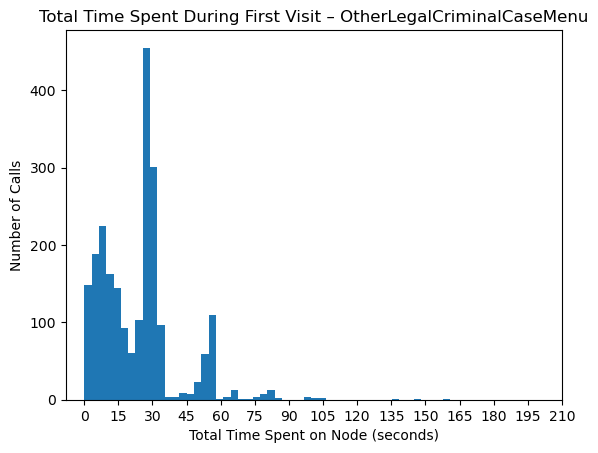

In [ ]:
# plot distribution for time spent during first visit 
plt.hist(otherlegalcriminal['total_time_first_time'], bins=50)
x_min = 0
x_max = int(otherlegalpersonalinjury['total_time_first_time'].max()) + 2
plt.xticks(np.arange(x_min, x_max, 15))
plt.xlabel('Total Time Spent on Node (seconds)')
plt.ylabel('Number of Calls')
plt.title('Total Time Spent During First Visit – OtherLegalCriminalCaseMenu')
plt.show()



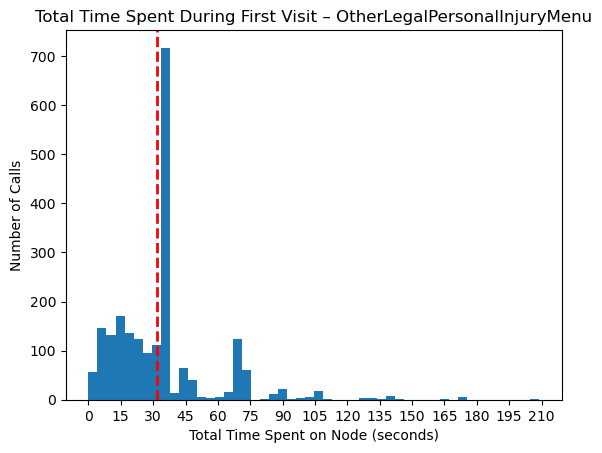

0.4274193548387097


In [21]:
prompt_length = 32 

plt.hist(otherlegalpersonalinjury['total_time_first_time'], bins=50)
plt.axvline(prompt_length, color='red', linestyle='--', linewidth=2, label='Prompt Length (32s)')
# Granular x-axis ticks (every 2 seconds)
x_min = 0
x_max = int(otherlegalpersonalinjury['total_time_first_time'].max()) + 2
plt.xticks(np.arange(x_min, x_max, 15))
plt.xlabel('Total Time Spent on Node (seconds)')
plt.ylabel('Number of Calls')
plt.title('Total Time Spent During First Visit – OtherLegalPersonalInjuryMenu')
plt.show()

# below prints fraction of callers who don't hear full prompt 
print(otherlegalpersonalinjury[otherlegalpersonalinjury['total_time_first_time'] < 32].shape[0]/otherlegalpersonalinjury.shape[0])


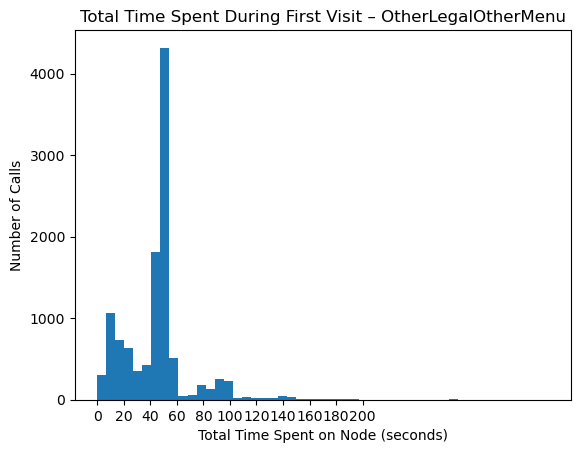

In [22]:
plt.hist(otherlegalother['total_time_first_time'], bins=50)
x_max = int(otherlegalpersonalinjury['total_time_first_time'].max()) + 2
plt.xticks(np.arange(x_min, x_max, 20))
plt.xlabel('Total Time Spent on Node (seconds)')
plt.ylabel('Number of Calls')
plt.title('Total Time Spent During First Visit – OtherLegalOtherMenu')
plt.show()